**Table of contents**<a id='toc0_'></a>    
- [EDA and data prep of official charging point data](#toc1_)    
  - [Data structure](#toc1_1_)    
  - [Charger types](#toc1_2_)    
  - [Largest operators of charging stations accross Germany](#toc1_3_)    
  - [Assigning charging stations to buses in scigrid](#toc1_4_)    
    - [Connected power per bus](#toc1_4_1_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[EDA and data prep of official charging point data](#toc0_)

__Abstract:__ The German regulatoric authority for power grids (BNetzA) publishes the location and static data of charging points accross Germany. We can utilize this data to assess the criticality of aggregators, where an aggregator is defined as the operator of a charging station. 

__Data availability:__ The data is available for download at [BNetza](https://www.bundesnetzagentur.de/DE/Fachthemen/ElektrizitaetundGas/E-Mobilitaet/start.html), the latest current version is provided in the Excel file, and is a snapshot from *18.07.2025*. 

__Regulatory obligation:__ All data analyses are based on the information provided by the operators of publicly accessible charging points as part of the notification procedure in accordance with Section 5 of the Charging Point Ordinance. All publicly accessible charging points with a charging capacity of more than 3.7 kW that have been put into operation since the ordinance came into force on 17 March 2016 must be reported to the Federal Network Agency. Fast charging points with a charging capacity of more than 22 kW are fully covered. Information on older normal charging points and charging points with a charging capacity of up to 3.7 kW is based on voluntary reports from the operators.

*Original:* "Hinweis zur Datengrundlage:
Alle Datenauswertungen basieren auf den Angaben der Betreiber öffentlich zugänglicher Ladepunkte im Rahmen des Anzeigeverfahrens nach § 5 Ladesäulenverordnung. Bei der Bundesnetzagentur meldepflichtig sind alle öffentlich zugänglichen Ladepunkte mit über 3,7 kW Ladeleistung, die seit dem Inkrafttreten der Verordnung am 17. März 2016 in Betrieb genommen wurden. Schnellladepunkte mit mehr als 22 kW Ladeleistung sind vollständig erfasst. Angaben zu älteren Normalladepunkte und Ladepunkten bis 3,7 kW Ladeleistung basieren auf freiwilligen Meldungen der Betreiber." [BNetzA in Laesaeuleninfrastrukturreport](https://www.bundesnetzagentur.de/SharedDocs/Downloads/DE/Sachgebiete/Energie/Unternehmen_Institutionen/E_Mobilitaet/Ladesaeuleninfrastruktur.xlsx?__blob=publicationFile&v=13) 

__Purpose of this notebook:__ Exploratory data analysis and preparation of the data, i.e., cleaning and translation to English.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from IPython.display import display
import matplotlib.pyplot as plt

## <a id='toc1_1_'></a>[Data structure](#toc0_)

__Existing cols and summary of those__

In [3]:
df_raw = pd.read_excel('Ladesaeulenregister_BNetzA_2025-07-18.xlsx', skiprows=10, decimal=',')

In [4]:
df_raw.head()

,Ladeeinrichtungs-ID,Betreiber,Anzeigename (Karte),Status,Art der Ladeeinrichtung,Anzahl Ladepunkte,Nennleistung Ladeeinrichtung [kW],Inbetriebnahmedatum,Straße,Hausnummer,...,EVSE-ID4,Public Key4,Steckertypen5,Nennleistung Stecker5,EVSE-ID5,Public Key5,Steckertypen6,Nennleistung Stecker6,EVSE-ID6,Public Key6
0,1010338,Albwerk Elektro- und Kommunikationstechnik GmbH,Albwerk Elektro- und Kommunikationstechnik GmbH,In Betrieb,Normalladeeinrichtung,2,22.0,2020-01-11,Ennabeurer Weg,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1063962,smopi® - Multi Chargepoint Solution GmbH,smopi,In Betrieb,Normalladeeinrichtung,4,22.0,2022-11-23,Albstraße,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1063963,smopi® - Multi Chargepoint Solution GmbH,smopi,In Betrieb,Normalladeeinrichtung,4,22.0,2022-11-23,Albstraße,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1063964,smopi® - Multi Chargepoint Solution GmbH,smopi,In Betrieb,Normalladeeinrichtung,2,22.0,2022-11-23,Albstraße,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1010329,Albwerk Elektro- und Kommunikationstechnik GmbH,Albwerk Elektro- und Kommunikationstechnik GmbH,In Betrieb,Normalladeeinrichtung,2,22.0,2019-01-07,Parkplatz Campingplatz,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92077 entries, 0 to 92076
Data columns (total 47 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Ladeeinrichtungs-ID                92077 non-null  int64         
 1   Betreiber                          92077 non-null  object        
 2   Anzeigename (Karte)                39986 non-null  object        
 3   Status                             92077 non-null  object        
 4   Art der Ladeeinrichtung            92077 non-null  object        
 5   Anzahl Ladepunkte                  92077 non-null  int64         
 6   Nennleistung Ladeeinrichtung [kW]  92077 non-null  float64       
 7   Inbetriebnahmedatum                92077 non-null  datetime64[ns]
 8   Straße                             92077 non-null  object        
 9   Hausnummer                         92077 non-null  object        
 10  Adresszusatz                      

In [6]:
df_raw.describe(include='all')

,Ladeeinrichtungs-ID,Betreiber,Anzeigename (Karte),Status,Art der Ladeeinrichtung,Anzahl Ladepunkte,Nennleistung Ladeeinrichtung [kW],Inbetriebnahmedatum,Straße,Hausnummer,...,EVSE-ID4,Public Key4,Steckertypen5,Nennleistung Stecker5,EVSE-ID5,Public Key5,Steckertypen6,Nennleistung Stecker6,EVSE-ID6,Public Key6
count,9.207700e+04,92077,39986,92077,92077,92077.000000,92077.000000,92077,92077,92077,...,250,781,103,103,49,36,93,93,45,34
unique,NaN,11201,1629,2,2,NaN,NaN,NaN,31364,2444,...,247,725,8,9,49,35,5,8,45,34
top,NaN,EnBW mobility+ AG und Co.KG,E.ON Drive GmbH,In Betrieb,Normalladeeinrichtung,NaN,NaN,NaN,Hauptstraße,1,...,DEKSLE009612,3059301306072a8648ce3d020106082a8648ce3d030107...,AC Typ 2 Steckdose,22,DE*ODR*E1000*0955,3059301306072a8648ce3d020106082a8648ce3d030107...,AC Typ 2 Steckdose,22,DE*ODR*E1000*0956,Road
freq,NaN,4374,2864,92057,69286,NaN,NaN,NaN,663,10316,...,2,6,62,66,1,2,58,64,1,1
mean,1.064981e+06,NaN,NaN,NaN,NaN,1.827177,71.769641,2022-07-04 01:25:23.364140544,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000e+06,NaN,NaN,NaN,NaN,1.000000,1.000000,1992-10-01 00:00:00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.034718e+06,NaN,NaN,NaN,NaN,1.000000,22.000000,2021-05-17 00:00:00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.062775e+06,NaN,NaN,NaN,NaN,2.000000,44.000000,2023-01-30 00:00:00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.099839e+06,NaN,NaN,NaN,NaN,2.000000,50.000000,2024-01-16 00:00:00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,1.130311e+06,NaN,NaN,NaN,NaN,6.000000,1200.000000,2025-07-18 00:00:00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


__Cols to select (GER):__ ID, Betreiber, Status, Art der Ladeeinrichtung, Anzahl Ladepunkte, Nennleistung Ladeeinrichtung, Postleitzahl, Ort, Kreis, Bundesland, Breitengrad, Längengrad

__Cols to select (ENG):__ ID, operator, status, type of charging facility, number of charging points, rated power of charging facility, postcode, city, district, federal state, latitude, longitude

__Clean names (ENG):__ ID, operator, status, type_charging, number_charging_points, rated_power_point_kW, ttl_rated_power (included), postcode, city, district, federal state, latitude, longitude


__Computation of the total power:__ 

The total power of a charging station is given by its rated charging power. Even though multiple charging points of a charging station may exist, the charging power cannot exceed the rated charging power.

The BNetzA reports "gesamte Ladeleistung von 6795 MW zum 01.07.2025. Bei der Ladeleistung handelt es sich um die kummulierte Nennleistung der Ladeeinrichtungen und nicht die Leistung der einzelnen Ladepunkte." We can compute 6608 MW by summing the column 'Nennleistung Ladeeinrichtung [kW]', which is fairly close. 
 

In [7]:
df_raw['Nennleistung Stecker1']=pd.to_numeric(df_raw['Nennleistung Stecker1'], errors='coerce')
df_raw['Nennleistung Ladeeinrichtung [kW]']=pd.to_numeric(df_raw['Nennleistung Ladeeinrichtung [kW]'], errors='coerce')
df_raw['Nennleistung Ladeeinrichtung [kW]'] = np.where(df_raw['Nennleistung Ladeeinrichtung [kW]'].isnull(), df_raw['Nennleistung Stecker1'], df_raw['Nennleistung Ladeeinrichtung [kW]'])
df_filter_ger = df_raw.filter(items=['Ladeeinrichtungs-ID', 'Betreiber', 'Anzeigename (Karte)','Status', 'Art der Ladeeinrichtung', 'Anzahl Ladepunkte', 'Nennleistung Ladeeinrichtung [kW]', 'Postleitzahl', 'Ort', 'Kreis/kreisfreie Stadt', 'Bundesland', 'Breitengrad', 'Längengrad'])
df_filter_ger['Betreiber_kurz'] = np.where(df_filter_ger['Anzeigename (Karte)'].isnull(), df_filter_ger['Betreiber'], df_filter_ger['Anzeigename (Karte)'])
df_filter_ger['Ttl_power_kW'] = df_filter_ger['Nennleistung Ladeeinrichtung [kW]'] #*df_filter_ger['Anzahl Ladepunkte'] 
df_filter_ger.drop(columns=['Anzeigename (Karte)'], inplace=True) 
df_filter_ger.head(100)

,Ladeeinrichtungs-ID,Betreiber,Status,Art der Ladeeinrichtung,Anzahl Ladepunkte,Nennleistung Ladeeinrichtung [kW],Postleitzahl,Ort,Kreis/kreisfreie Stadt,Bundesland,Breitengrad,Längengrad,Betreiber_kurz,Ttl_power_kW
0,1010338,Albwerk Elektro- und Kommunikationstechnik GmbH,In Betrieb,Normalladeeinrichtung,2,22.0,72535,Heroldstatt,Landkreis Alb-Donau-Kreis,Baden-Württemberg,48.442398,9.659075,Albwerk Elektro- und Kommunikationstechnik GmbH,22.0
1,1063962,smopi® - Multi Chargepoint Solution GmbH,In Betrieb,Normalladeeinrichtung,4,22.0,72535,Heroldstatt,Landkreis Alb-Donau-Kreis,Baden-Württemberg,48.449424,9.672201,smopi,22.0
2,1063963,smopi® - Multi Chargepoint Solution GmbH,In Betrieb,Normalladeeinrichtung,4,22.0,72535,Heroldstatt,Landkreis Alb-Donau-Kreis,Baden-Württemberg,48.449424,9.672201,smopi,22.0
3,1063964,smopi® - Multi Chargepoint Solution GmbH,In Betrieb,Normalladeeinrichtung,2,22.0,72535,Heroldstatt,Landkreis Alb-Donau-Kreis,Baden-Württemberg,48.449424,9.672201,smopi,22.0
4,1010329,Albwerk Elektro- und Kommunikationstechnik GmbH,In Betrieb,Normalladeeinrichtung,2,22.0,72589,Westerheim,Landkreis Alb-Donau-Kreis,Baden-Württemberg,48.510500,9.609000,Albwerk Elektro- und Kommunikationstechnik GmbH,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1071555,Katrin Schneiderhan,In Betrieb,Normalladeeinrichtung,1,16.7,89155,Erbach,Landkreis Alb-Donau-Kreis,Baden-Württemberg,48.304437,9.905832,Katrin Schneiderhan,16.7
96,1087930,Stephen Böhm,In Betrieb,Normalladeeinrichtung,1,11.0,89155,Erbach,Landkreis Alb-Donau-Kreis,Baden-Württemberg,48.297647,9.901748,Stephen Böhm,11.0
97,1025690,EnBW mobility+ AG und Co.KG,In Betrieb,Normalladeeinrichtung,2,30.0,89160,Dornstadt (Bollingen),Landkreis Alb-Donau-Kreis,Baden-Württemberg,48.454940,9.911473,EnBW mobility+ AG und Co.KG,30.0
98,1025691,EnBW mobility+ AG und Co.KG,In Betrieb,Normalladeeinrichtung,2,30.0,89160,Dornstadt,Landkreis Alb-Donau-Kreis,Baden-Württemberg,48.464622,9.941352,EnBW mobility+ AG und Co.KG,30.0


In [8]:

df_filter_eng = df_filter_ger.rename(columns={
    'Ladeeinrichtungs-ID': 'ID',
    'Betreiber': 'operator',
    'Betreiber_kurz': 'operator_short',
    'Status': 'status',
    'Art der Ladeeinrichtung': 'type_charging',
    'Anzahl Ladepunkte': 'number_charging_points',
    'Nennleistung Ladeeinrichtung [kW]': 'rated_power_point_kW',
    'Ttl_power_kW': 'ttl_power_kW',
    'Postleitzahl': 'postcode',
    'Ort': 'city',
    'Kreis/kreisfreie Stadt': 'district',
    'Bundesland': 'federal_state',
    'Breitengrad': 'latitude',
    'Längengrad': 'longitude'
})
df_filter_eng['type_charging'] = df_filter_eng['type_charging'].str.replace('Schnellladeeinrichtung', 'Fast charger')
df_filter_eng['type_charging'] = df_filter_eng['type_charging'].str.replace('Normalladeeinrichtung', 'Normal charger')


In [9]:
#* write to csv
df_filter_eng.to_csv('Ladesaeulenregister_BNetzA_2025-07-18_engl_brief.csv', index=False)
df_filter_ger.to_csv('Ladesaeulenregister_BNetzA_2025-07-18_dt_kurz.csv', index=False)

In [10]:
df_wirelane = df_filter_ger[df_filter_ger['Betreiber'] == 'Wirelane GmbH']
df_wirelane

,Ladeeinrichtungs-ID,Betreiber,Status,Art der Ladeeinrichtung,Anzahl Ladepunkte,Nennleistung Ladeeinrichtung [kW],Postleitzahl,Ort,Kreis/kreisfreie Stadt,Bundesland,Breitengrad,Längengrad,Betreiber_kurz,Ttl_power_kW
633,1111560,Wirelane GmbH,In Betrieb,Normalladeeinrichtung,2,22.0,88422,Dürnau,Landkreis Biberach,Baden-Württemberg,48.059260,9.554805,Wirelane GmbH,22.0
3890,1111437,Wirelane GmbH,In Betrieb,Normalladeeinrichtung,2,22.0,73342,Bad Ditzenbach-Auendorf,Landkreis Göppingen,Baden-Württemberg,48.609823,9.679813,Wirelane GmbH,22.0
3891,1111559,Wirelane GmbH,In Betrieb,Normalladeeinrichtung,2,22.0,73342,Bad Ditzenbach-Auendorf,Landkreis Göppingen,Baden-Württemberg,48.609823,9.679813,Wirelane GmbH,22.0
5191,1111522,Wirelane GmbH,In Betrieb,Normalladeeinrichtung,2,22.0,76689,Karlsdorf-Neuthard,Landkreis Karlsruhe,Baden-Württemberg,49.149168,8.545907,Wirelane GmbH,22.0
5192,1111586,Wirelane GmbH,In Betrieb,Normalladeeinrichtung,2,22.0,76689,Karlsdorf-Neuthard,Landkreis Karlsruhe,Baden-Württemberg,49.149168,8.545907,Wirelane GmbH,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87446,1111776,Wirelane GmbH,In Betrieb,Normalladeeinrichtung,2,22.0,25980,Sylt,Kreis Nordfriesland,Schleswig-Holstein,54.902789,8.299131,Wirelane GmbH,22.0
88183,1111439,Wirelane GmbH,In Betrieb,Normalladeeinrichtung,2,22.0,24321,Lütjenburg,Kreis Plön,Schleswig-Holstein,54.291397,10.587493,Wirelane GmbH,22.0
88184,1111527,Wirelane GmbH,In Betrieb,Normalladeeinrichtung,1,22.0,24321,Lütjenburg,Kreis Plön,Schleswig-Holstein,54.291397,10.587493,Wirelane GmbH,22.0
89877,1111409,Wirelane GmbH,In Betrieb,Normalladeeinrichtung,2,22.0,23554,Lübeck,Kreisfreie Stadt Lübeck,Schleswig-Holstein,53.873756,10.666361,Wirelane GmbH,22.0


## <a id='toc1_2_'></a>[Charger types](#toc0_)

In [11]:
ttl_power_mw = df_filter_eng['ttl_power_kW'].sum()/1000
df_res = df_filter_eng.groupby(['type_charging']).agg({'number_charging_points': 'sum', 'ttl_power_kW': 'sum'}).reset_index()
df_res['ttl_power_MW'] = df_res['ttl_power_kW']/1000
df_res.drop(columns=['ttl_power_kW'], inplace=True)
df_res['ttl_power_MW_perc'] = df_res['ttl_power_MW']/ttl_power_mw
display(df_res.round(decimals=2))

,type_charging,number_charging_points,ttl_power_MW,ttl_power_MW_perc
0,Fast charger,42925,4623.43,0.7
1,Normal charger,125316,1984.90,0.3


<Axes: xlabel='rated_power_point_kW', ylabel='Count'>

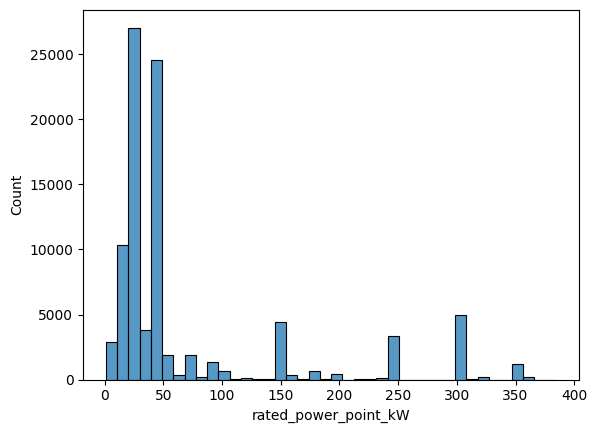

In [12]:
sns.histplot(df_filter_eng[df_filter_eng['rated_power_point_kW'] < 400], x='rated_power_point_kW', bins=40)

## <a id='toc1_3_'></a>[Largest operators of charging stations accross Germany](#toc0_)

In [13]:
df_operator = df_filter_eng.groupby(['operator_short']).agg({'number_charging_points': 'sum', 'ttl_power_kW': 'sum'}).reset_index()
df_operator = df_operator.sort_values(by='ttl_power_kW', ascending=False)
df_operator.describe(include='all')

,operator_short,number_charging_points,ttl_power_kW
count,11183,11183.000000,11183.000000
unique,11183,NaN,NaN
top,Tesla Germany GmbH,NaN,NaN
freq,1,NaN,NaN
mean,NaN,15.044353,590.926692
std,NaN,135.701057,12716.623666
min,NaN,1.000000,1.000000
25%,NaN,1.000000,11.000000
50%,NaN,2.000000,22.000000
75%,NaN,4.000000,66.000000


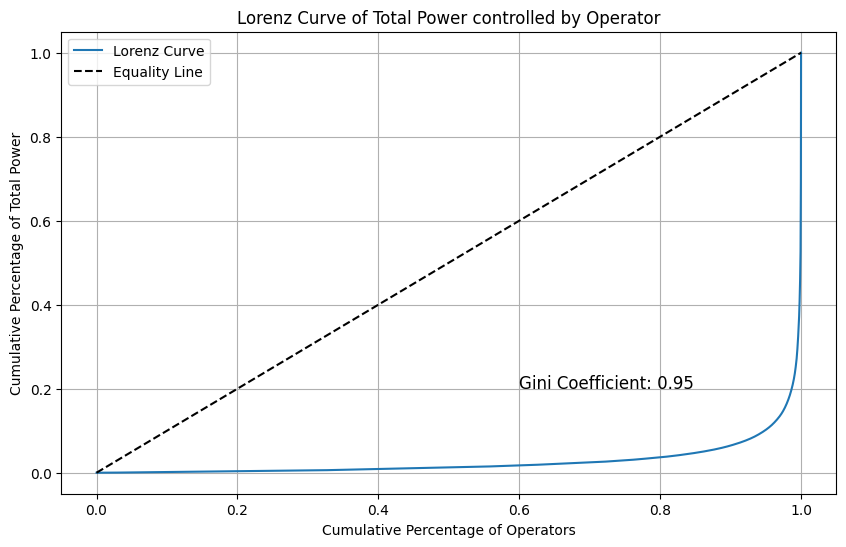

In [14]:


df_operator_sorted = df_operator.sort_values(by='ttl_power_kW')

# Calculate cumulative sums and percentages
cumulative_power = df_operator_sorted['ttl_power_kW'].cumsum()
cumulative_percentage_power = cumulative_power / cumulative_power.iloc[-1]
cumulative_percentage_operators = np.arange(1, len(cumulative_power) + 1) / len(cumulative_power)

# Create a DataFrame for Seaborn
lorenz_df = pd.DataFrame({
    'Cumulative Percentage of Operators': cumulative_percentage_operators,
    'Cumulative Percentage of Total Power': cumulative_percentage_power
})
gini_coeff = 1 - 2 * (lorenz_df['Cumulative Percentage of Total Power'].sum() / len(lorenz_df))
# Plot using Seaborn
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=lorenz_df, 
    x='Cumulative Percentage of Operators', 
    y='Cumulative Percentage of Total Power', 
    label='Lorenz Curve'
)

# Add equality line
sns.lineplot(x=[0, 1], y=[0, 1], linestyle='--', color='black', label='Equality Line')

# Customize plot
plt.xlabel('Cumulative Percentage of Operators')
plt.ylabel('Cumulative Percentage of Total Power')
plt.title('Lorenz Curve of Total Power controlled by Operator')
plt.annotate(f'Gini Coefficient: {gini_coeff:.2f}', xy=(0.6, 0.2), fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df_operator_filt = df_operator[df_operator['ttl_power_kW'] >= 100]
df_operator_filt.loc[:,("Share_Perc")] = (df_operator_filt["ttl_power_kW"] / df_operator_filt["ttl_power_kW"].sum())*100
df_operator_filt.loc[:,"ttl_power_MW"] = df_operator_filt["ttl_power_kW"]/1000
df_operator_filt=df_operator_filt.drop(columns=["ttl_power_kW"])
df_operator_filt.reset_index(drop=True, inplace=True)

__Top 25 operators by total operated/installed power__

In [16]:
display(df_operator_filt.round(decimals=3).head(25))

,operator_short,number_charging_points,Share_Perc,ttl_power_MW
0,Tesla Germany GmbH,3400,13.211,840.600
1,EnBW mobility+ AG und Co.KG,9201,12.438,791.421
2,IONITY GmbH,1242,6.362,404.800
3,Aral Pulse,2163,4.714,299.954
4,Shell Deutschland GmbH,1655,3.599,228.973
5,EWE Go GmbH,2758,3.298,209.860
6,Allego,2288,2.860,181.975
7,Pfalzwerke AG,1957,2.620,166.699
8,Citywatt GmbH,1118,1.317,83.773
9,MER Germany,1893,1.254,79.761


## <a id='toc1_4_'></a>[Assigning charging stations to buses in scigrid](#toc0_)

__Mssignment logic:__ We use the [Nearest Centroid Classifier](https://scikit-learn.org/stable/modules/neighbors.html#nearest-centroid-classifier) centered at the *buses containing 110kV substations in scrigrid* and assign the charging stations according to the centroids/buses. 



In [17]:
from sklearn.neighbors import NearestCentroid
bus_data = pd.read_csv('C:/GitFolder/aggregator_assessment/scigrid_data/scigrid_raw/buses.csv')

In [18]:
bus_data_filt = bus_data[bus_data['voltage'].str.contains('110000', na=False)]
X = bus_data_filt[['x', 'y']].values
y = bus_data_filt['name'].values


In [19]:
clf = NearestCentroid()
clf.fit(X, y)

c:\GitFolder\aggregator_assessment\agg_assessment_py\Lib\site-packages\sklearn\neighbors\_nearest_centroid.py:241: RuntimeWarning: invalid value encountered in divide
  np.sqrt(variance.sum(axis=0) / (n_samples - n_classes)), copy=False


NearestCentroid()

In [20]:
df_filter_eng.head(30)

,ID,operator,status,type_charging,number_charging_points,rated_power_point_kW,postcode,city,district,federal_state,latitude,longitude,operator_short,ttl_power_kW
0,1010338,Albwerk Elektro- und Kommunikationstechnik GmbH,In Betrieb,Normal charger,2,22.0,72535,Heroldstatt,Landkreis Alb-Donau-Kreis,Baden-Württemberg,48.442398,9.659075,Albwerk Elektro- und Kommunikationstechnik GmbH,22.0
1,1063962,smopi® - Multi Chargepoint Solution GmbH,In Betrieb,Normal charger,4,22.0,72535,Heroldstatt,Landkreis Alb-Donau-Kreis,Baden-Württemberg,48.449424,9.672201,smopi,22.0
2,1063963,smopi® - Multi Chargepoint Solution GmbH,In Betrieb,Normal charger,4,22.0,72535,Heroldstatt,Landkreis Alb-Donau-Kreis,Baden-Württemberg,48.449424,9.672201,smopi,22.0
3,1063964,smopi® - Multi Chargepoint Solution GmbH,In Betrieb,Normal charger,2,22.0,72535,Heroldstatt,Landkreis Alb-Donau-Kreis,Baden-Württemberg,48.449424,9.672201,smopi,22.0
4,1010329,Albwerk Elektro- und Kommunikationstechnik GmbH,In Betrieb,Normal charger,2,22.0,72589,Westerheim,Landkreis Alb-Donau-Kreis,Baden-Württemberg,48.510500,9.609000,Albwerk Elektro- und Kommunikationstechnik GmbH,22.0
5,1025458,EnBW mobility+ AG und Co.KG,In Betrieb,Fast charger,2,93.0,73340,Amstetten,Landkreis Alb-Donau-Kreis,Baden-Württemberg,48.578534,9.874840,EnBW mobility+ AG und Co.KG,93.0
6,1120617,Gasthaus & Albhotel zum Bahnhöfle,In Betrieb,Normal charger,2,22.0,73340,Amstetten,Landkreis Alb-Donau-Kreis,Baden-Württemberg,48.595016,9.921854,Gasthaus & Albhotel zum Bahnhöfle,22.0
7,1121121,Gasthaus & Albhotel zum Bahnhöfle,In Betrieb,Normal charger,2,22.0,73340,Amstetten,Landkreis Alb-Donau-Kreis,Baden-Württemberg,48.595016,9.921854,Gasthaus & Albhotel zum Bahnhöfle,22.0
8,1033071,SWU Energie GmbH,In Betrieb,Normal charger,2,44.0,88481,Balzheim,Landkreis Alb-Donau-Kreis,Baden-Württemberg,48.179959,10.076977,SWU Energie GmbH,44.0
9,1009242,Shell Deutschland GmbH,In Betrieb,Fast charger,2,300.0,89129,Langenau,Landkreis Alb-Donau-Kreis,Baden-Württemberg,48.493390,10.107830,Shell Deutschland GmbH,300.0


In [21]:
df_filter_eng['Bus_scigrid_NC_euclidean'] =clf.predict(df_filter_eng[['longitude','latitude']].values)
df_filter_ger['Bus_scigrid_NC_euclidean'] =clf.predict(df_filter_eng[['longitude','latitude']].values)

In [22]:
df_filter_eng = pd.merge(df_filter_eng, bus_data_filt.filter(items = ['name', 'x','y','osm_name', 'type', 'voltage']), left_on='Bus_scigrid_NC_euclidean', right_on='name', how='left')

In [23]:
df_filter_eng.to_csv('Ladesaeulenregister_BNetzA_2025-07-18_engl_brief.csv', index=False)
df_filter_ger.to_csv('Ladesaeulenregister_BNetzA_2025-07-18_dt_kurz.csv', index=False)

In [24]:
df_filter_eng

,ID,operator,status,type_charging,number_charging_points,rated_power_point_kW,postcode,city,district,federal_state,latitude,longitude,operator_short,ttl_power_kW,Bus_scigrid_NC_euclidean,name,x,y,osm_name,voltage
0,1010338,Albwerk Elektro- und Kommunikationstechnik GmbH,In Betrieb,Normal charger,2,22.0,72535,Heroldstatt,Landkreis Alb-Donau-Kreis,Baden-Württemberg,48.442398,9.659075,Albwerk Elektro- und Kommunikationstechnik GmbH,22.0,319,319,9.704231,48.465064,EnBW Umspannwerk Laichingen,380000;110000
1,1063962,smopi® - Multi Chargepoint Solution GmbH,In Betrieb,Normal charger,4,22.0,72535,Heroldstatt,Landkreis Alb-Donau-Kreis,Baden-Württemberg,48.449424,9.672201,smopi,22.0,319,319,9.704231,48.465064,EnBW Umspannwerk Laichingen,380000;110000
2,1063963,smopi® - Multi Chargepoint Solution GmbH,In Betrieb,Normal charger,4,22.0,72535,Heroldstatt,Landkreis Alb-Donau-Kreis,Baden-Württemberg,48.449424,9.672201,smopi,22.0,319,319,9.704231,48.465064,EnBW Umspannwerk Laichingen,380000;110000
3,1063964,smopi® - Multi Chargepoint Solution GmbH,In Betrieb,Normal charger,2,22.0,72535,Heroldstatt,Landkreis Alb-Donau-Kreis,Baden-Württemberg,48.449424,9.672201,smopi,22.0,319,319,9.704231,48.465064,EnBW Umspannwerk Laichingen,380000;110000
4,1010329,Albwerk Elektro- und Kommunikationstechnik GmbH,In Betrieb,Normal charger,2,22.0,72589,Westerheim,Landkreis Alb-Donau-Kreis,Baden-Württemberg,48.510500,9.609000,Albwerk Elektro- und Kommunikationstechnik GmbH,22.0,319,319,9.704231,48.465064,EnBW Umspannwerk Laichingen,380000;110000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92072,1077589,Energieversorgung Apolda GmbH,In Betrieb,Normal charger,2,44.0,99518,Bad Sulza,Landkreis Weimarer Land,Thüringen,51.096202,11.628901,Energieversorgung Apolda GmbH,44.0,441,441,11.470394,50.930390,Großschwabhausen,380000;110000
92073,1086723,Marcus Altschwager,In Betrieb,Normal charger,1,3.0,99518,Niedertrebra,Landkreis Weimarer Land,Thüringen,51.068591,11.583716,Marcus Altschwager,3.0,441,441,11.470394,50.930390,Großschwabhausen,380000;110000
92074,1087762,Sindy Schneiderhan,In Betrieb,Normal charger,1,3.0,99518,Niedertrebra,Landkreis Weimarer Land,Thüringen,51.068591,11.583716,Sindy Schneiderhan,3.0,441,441,11.470394,50.930390,Großschwabhausen,380000;110000
92075,1118314,TEAG Mobil GmbH,In Betrieb,Normal charger,2,22.0,99518,Bad Sulza,Landkreis Weimarer Land,Thüringen,51.093799,11.623401,TEAG Mobil GmbH,22.0,441,441,11.470394,50.930390,Großschwabhausen,380000;110000


### <a id='toc1_4_1_'></a>[Connected power per bus](#toc0_)

In [25]:
print(f"Buses scigrid with 110kV level: {bus_data_filt['name'].nunique()}")
print(f"Buses with at least 1 assigned charging station: {df_filter_eng['Bus_scigrid_NC_euclidean'].nunique()}")

Buses scigrid with 110kV level: 367
Buses with at least 1 assigned charging station: 299


In [26]:
df_car2bus = df_filter_eng.groupby(['Bus_scigrid_NC_euclidean']).agg({'number_charging_points': 'sum', 'ttl_power_kW': 'sum'}).reset_index()
df_car2bus = df_car2bus.sort_values(by='ttl_power_kW', ascending=False)
df_car2bus.describe().round(decimals=2)

,number_charging_points,ttl_power_kW
count,299.00,299.00
mean,562.68,22101.45
std,513.12,17892.80
min,4.00,44.00
25%,264.50,9817.00
50%,418.00,17794.00
75%,654.50,28760.50
max,3635.00,112744.00


In [27]:
df_filter_eng[df_filter_eng['postcode'] == 63897]

,ID,operator,status,type_charging,number_charging_points,rated_power_point_kW,postcode,city,district,federal_state,latitude,longitude,operator_short,ttl_power_kW,Bus_scigrid_NC_euclidean,name,x,y,osm_name,voltage
28205,1005873,EMB Energieversorgung Miltenberg - Bürgstadt G...,In Betrieb,Normal charger,2,44.0,63897,Miltenberg,Landkreis Miltenberg,Bayern,49.704775,9.252369,EMB Energieversorgung Miltenberg - Bürgstadt G...,44.0,309,309,9.446919,49.590263,Umspannwerk Höpfingen,380000;110000
28206,1005874,EMB Energieversorgung Miltenberg - Bürgstadt G...,In Betrieb,Normal charger,2,44.0,63897,Miltenberg,Landkreis Miltenberg,Bayern,49.704775,9.252369,EMB Energieversorgung Miltenberg - Bürgstadt G...,44.0,309,309,9.446919,49.590263,Umspannwerk Höpfingen,380000;110000
28207,1005876,EMB Energieversorgung Miltenberg - Bürgstadt G...,In Betrieb,Normal charger,2,44.0,63897,Miltenberg,Landkreis Miltenberg,Bayern,49.700970,9.257523,EMB Energieversorgung Miltenberg - Bürgstadt G...,44.0,309,309,9.446919,49.590263,Umspannwerk Höpfingen,380000;110000
28208,1005877,EMB Energieversorgung Miltenberg - Bürgstadt G...,In Betrieb,Normal charger,2,44.0,63897,Miltenberg,Landkreis Miltenberg,Bayern,49.705396,9.249174,EMB Energieversorgung Miltenberg - Bürgstadt G...,44.0,309,309,9.446919,49.590263,Umspannwerk Höpfingen,380000;110000
28209,1005878,EMB Energieversorgung Miltenberg - Bürgstadt G...,In Betrieb,Normal charger,2,44.0,63897,Miltenberg,Landkreis Miltenberg,Bayern,49.704279,9.258321,EMB Energieversorgung Miltenberg - Bürgstadt G...,44.0,309,309,9.446919,49.590263,Umspannwerk Höpfingen,380000;110000
28210,1081447,Autohaus Heermann und Rhein GmbH,In Betrieb,Normal charger,4,88.0,63897,Miltenberg,Landkreis Miltenberg,Bayern,49.705383,9.228540,Autohaus Heermann und Rhein GmbH,88.0,309,309,9.446919,49.590263,Umspannwerk Höpfingen,380000;110000
28211,1089952,Sparkasse Aschaffenburg Miltenberg AdöR,In Betrieb,Normal charger,1,22.0,63897,Miltenberg,Landkreis Miltenberg,Bayern,49.703030,9.257590,Sparkasse Aschaffenburg Miltenberg AdöR,22.0,309,309,9.446919,49.590263,Umspannwerk Höpfingen,380000;110000
28212,1089953,Sparkasse Aschaffenburg Miltenberg AdöR,In Betrieb,Normal charger,1,22.0,63897,Miltenberg,Landkreis Miltenberg,Bayern,49.703030,9.257590,Sparkasse Aschaffenburg Miltenberg AdöR,22.0,309,309,9.446919,49.590263,Umspannwerk Höpfingen,380000;110000
28213,1089954,Sparkasse Aschaffenburg Miltenberg AdöR,In Betrieb,Normal charger,1,22.0,63897,Miltenberg,Landkreis Miltenberg,Bayern,49.703030,9.257590,Sparkasse Aschaffenburg Miltenberg AdöR,22.0,309,309,9.446919,49.590263,Umspannwerk Höpfingen,380000;110000
28214,1089955,Sparkasse Aschaffenburg Miltenberg AdöR,In Betrieb,Normal charger,1,22.0,63897,Miltenberg,Landkreis Miltenberg,Bayern,49.703030,9.257590,Sparkasse Aschaffenburg Miltenberg AdöR,22.0,309,309,9.446919,49.590263,Umspannwerk Höpfingen,380000;110000


__*Plausibility:*__ Usually these EV charging stations in Miltenberg should be connected to the Umspannwerke Großheubach (110/20) or Amorbach (110/20) in close proximity (5-10km), instead Höpfingen was chosen (20km). This is due to Umspannwerk Großheubach and Amorbach missing in the Scigrid data set. Evaluated visually by the [map](https://openinframap.org/#11.21/49.6746/9.4354).